In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

See in the theory part that which type of output line we want to create... also keep in mind that it is without overfitting

1. Basically you get the some kind of curv shape data with quadratic quation
2. That's why using qadratic data we created the plot below.

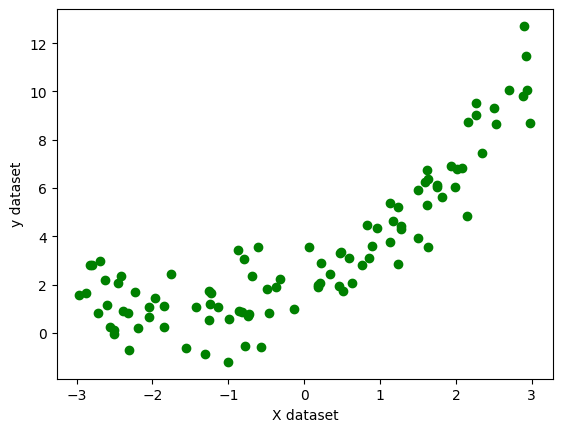

In [2]:
X = 6 * np.random.rand(100, 1) - 3   # Getting 100 samples with some Outliers
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)  # quadratic eq.: y = 0.5*X^2 + 1.5*X + 2 + Outliers 

plt.scatter(X, y, color='green')
plt.xlabel('X dataset')
plt.ylabel('y dataset')
plt.show()

First we gone implement upon our data simple linear regression and after developing Polynomial regression and then we get more idea about how the accuracy get improve.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
# Lets implement Simple linear regression

from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

In [5]:
regression_1.fit(X_train, y_train)

LinearRegression()

In [6]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
score

0.8026555085865258

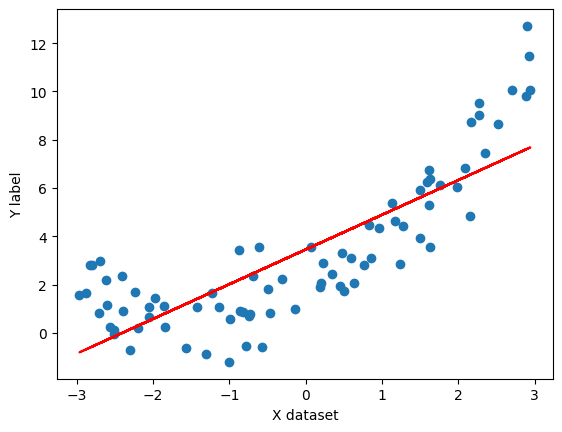

In [7]:
# Lets visulize the image
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X dataset")
plt.ylabel("Y label")
plt.show()

As U can see here our line is not predicting perefectly right. 
Now we gone develop through polynomial model

In [8]:
# Lets apply Polynomial transformation

from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True)  # degree 2 for x^2 & include_bias for beta_0
# The eq is like:
# h(theta) = beta_0 + beta_1*X_1 + beta_2*(X_2^2)

In [10]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
X_train_poly
# First_col, second_col(X^1), third_col(X^2)

array([[ 1.00000000e+00,  1.75435271e+00,  3.07775345e+00],
       [ 1.00000000e+00, -2.30472315e+00,  5.31174879e+00],
       [ 1.00000000e+00, -1.14118716e+00,  1.30230813e+00],
       [ 1.00000000e+00,  2.52374524e+00,  6.36929004e+00],
       [ 1.00000000e+00,  1.83382338e-01,  3.36290819e-02],
       [ 1.00000000e+00,  1.23081559e+00,  1.51490701e+00],
       [ 1.00000000e+00,  2.88026395e+00,  8.29592040e+00],
       [ 1.00000000e+00, -7.46038914e-01,  5.56574061e-01],
       [ 1.00000000e+00, -1.00469236e+00,  1.00940673e+00],
       [ 1.00000000e+00, -5.68366799e-01,  3.23040818e-01],
       [ 1.00000000e+00,  2.15884025e+00,  4.66059121e+00],
       [ 1.00000000e+00, -2.23353097e+00,  4.98866061e+00],
       [ 1.00000000e+00, -8.77130027e-01,  7.69357084e-01],
       [ 1.00000000e+00,  2.14826378e+00,  4.61503729e+00],
       [ 1.00000000e+00,  2.08370401e+00,  4.34182239e+00],
       [ 1.00000000e+00,  2.92821370e+00,  8.57443548e+00],
       [ 1.00000000e+00,  1.49798159e+00

In [12]:
X_test_poly

array([[ 1.        , -2.45719846,  6.03782427],
       [ 1.        ,  1.23055935,  1.51427631],
       [ 1.        ,  0.89363547,  0.79858436],
       [ 1.        , -1.25576198,  1.57693814],
       [ 1.        ,  2.50094204,  6.2547111 ],
       [ 1.        , -1.24886031,  1.55965207],
       [ 1.        ,  1.28131577,  1.64177011],
       [ 1.        ,  2.01964696,  4.07897384],
       [ 1.        ,  0.1864608 ,  0.03476763],
       [ 1.        , -1.7505179 ,  3.06431292],
       [ 1.        ,  1.75272457,  3.07204342],
       [ 1.        ,  0.48559106,  0.23579868],
       [ 1.        , -2.32505951,  5.40590174],
       [ 1.        ,  2.98082595,  8.88532337],
       [ 1.        ,  1.81130567,  3.28082823],
       [ 1.        , -1.24048684,  1.53880761],
       [ 1.        , -0.37557492,  0.14105652],
       [ 1.        ,  1.928429  ,  3.71883843],
       [ 1.        ,  1.13301629,  1.28372591],
       [ 1.        , -0.79090656,  0.62553318]])

In [13]:
# r2 score
from sklearn.metrics import r2_score
regression = LinearRegression()

In [14]:
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8565786493843344


In [15]:
print(regression.coef_)

[[0.         1.54123223 0.52933173]]


In [16]:
print(regression.intercept_)

[1.78640395]


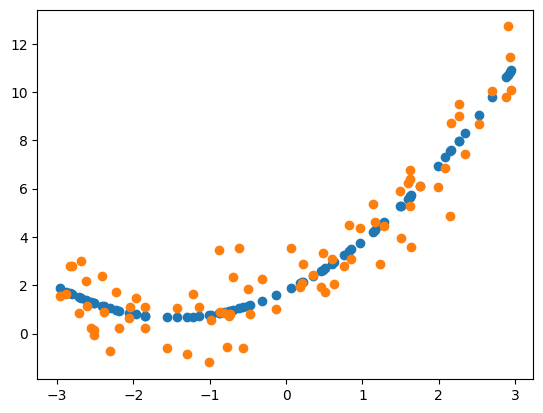

In [17]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)
plt.show()

In [18]:
# Increased the degree by 1

poly = PolynomialFeatures(degree=3, include_bias=True) 
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [19]:
X_train_poly

array([[ 1.00000000e+00,  1.75435271e+00,  3.07775345e+00,
         5.39946512e+00],
       [ 1.00000000e+00, -2.30472315e+00,  5.31174879e+00,
        -1.22421104e+01],
       [ 1.00000000e+00, -1.14118716e+00,  1.30230813e+00,
        -1.48617731e+00],
       [ 1.00000000e+00,  2.52374524e+00,  6.36929004e+00,
         1.60744654e+01],
       [ 1.00000000e+00,  1.83382338e-01,  3.36290819e-02,
         6.16697968e-03],
       [ 1.00000000e+00,  1.23081559e+00,  1.51490701e+00,
         1.86457116e+00],
       [ 1.00000000e+00,  2.88026395e+00,  8.29592040e+00,
         2.38944404e+01],
       [ 1.00000000e+00, -7.46038914e-01,  5.56574061e-01,
        -4.15225908e-01],
       [ 1.00000000e+00, -1.00469236e+00,  1.00940673e+00,
        -1.01414323e+00],
       [ 1.00000000e+00, -5.68366799e-01,  3.23040818e-01,
        -1.83605675e-01],
       [ 1.00000000e+00,  2.15884025e+00,  4.66059121e+00,
         1.00614719e+01],
       [ 1.00000000e+00, -2.23353097e+00,  4.98866061e+00,
      

In [20]:
from sklearn.metrics import r2_score

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.856692602334435


In [21]:
# So our previous accuracy is more compare to this one so we gone go with degree=2.

# Prediction for new data

In [22]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

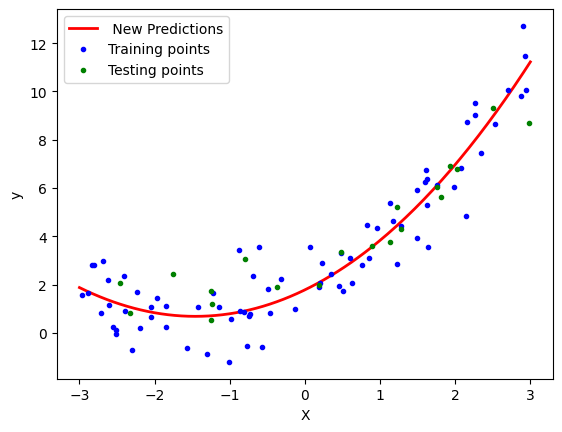

In [23]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concept 
In this you gone see generic function that gone accept degree value that you gone assign and create curve according to that. 

In [24]:
from sklearn.pipeline import Pipeline

In [38]:
from cProfile import label


def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)                # first polynomial regression then linear regression
    ])          
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)

    # Plotting prediction line
    plt.plot(X_new, y_pred_new, "r", linewidth=2, label="Degree" + str(degree))
    plt.plot(X_train, y_train, "b.",linewidth=3, label="training data")
    plt.plot(X_test, y_test, "g.",linewidth=3, label="test data")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend(loc="upper left")
    plt.axis([-4,4,0,10])
    plt.show()

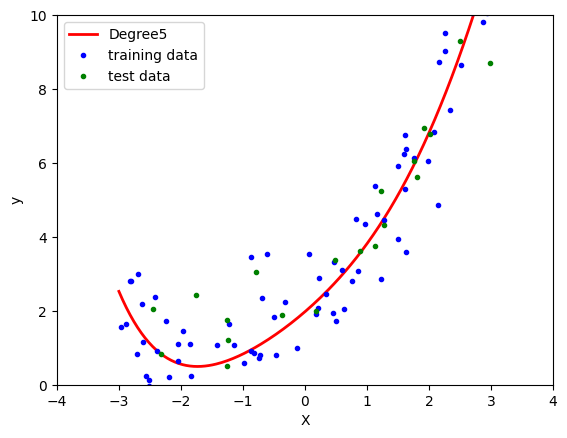

In [39]:
poly_regression(5)